In [151]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [152]:
import numpy as np
from scipy import linalg as la
from matplotlib import pyplot as plt
import matplotlib
import matplotlib.ticker as tck

from blochK.hamiltonian_engineering import (
    constraints_from_weyl_node,
    total_matrix_from_constraints,
    solve_constraint_matrix,
    vector_to_t_values,
    t_values_to_vector,
    d_vector,
)

from blochK.hamiltonian_engineering.plotting import plot_3d_d_matrix


matplotlib.rcParams.update(
    {
        "font.size": 10,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Palatino"],
    }
)

Hamiltonians are parametrised by a $t$-dictionary, which is provided as a set of:

$(\textup{hopping direction}) : (t_0, t_x, t_y, t_z)$

This indicates a hopping of the form $t_\mu \sigma_\mu$, or

$\begin{pmatrix}
t_0 + t_z & t_x -i t_y \\
t_x + i t_y& t_0 - t_z  
\end{pmatrix}$

Of course, $t$ values can be imaginary.

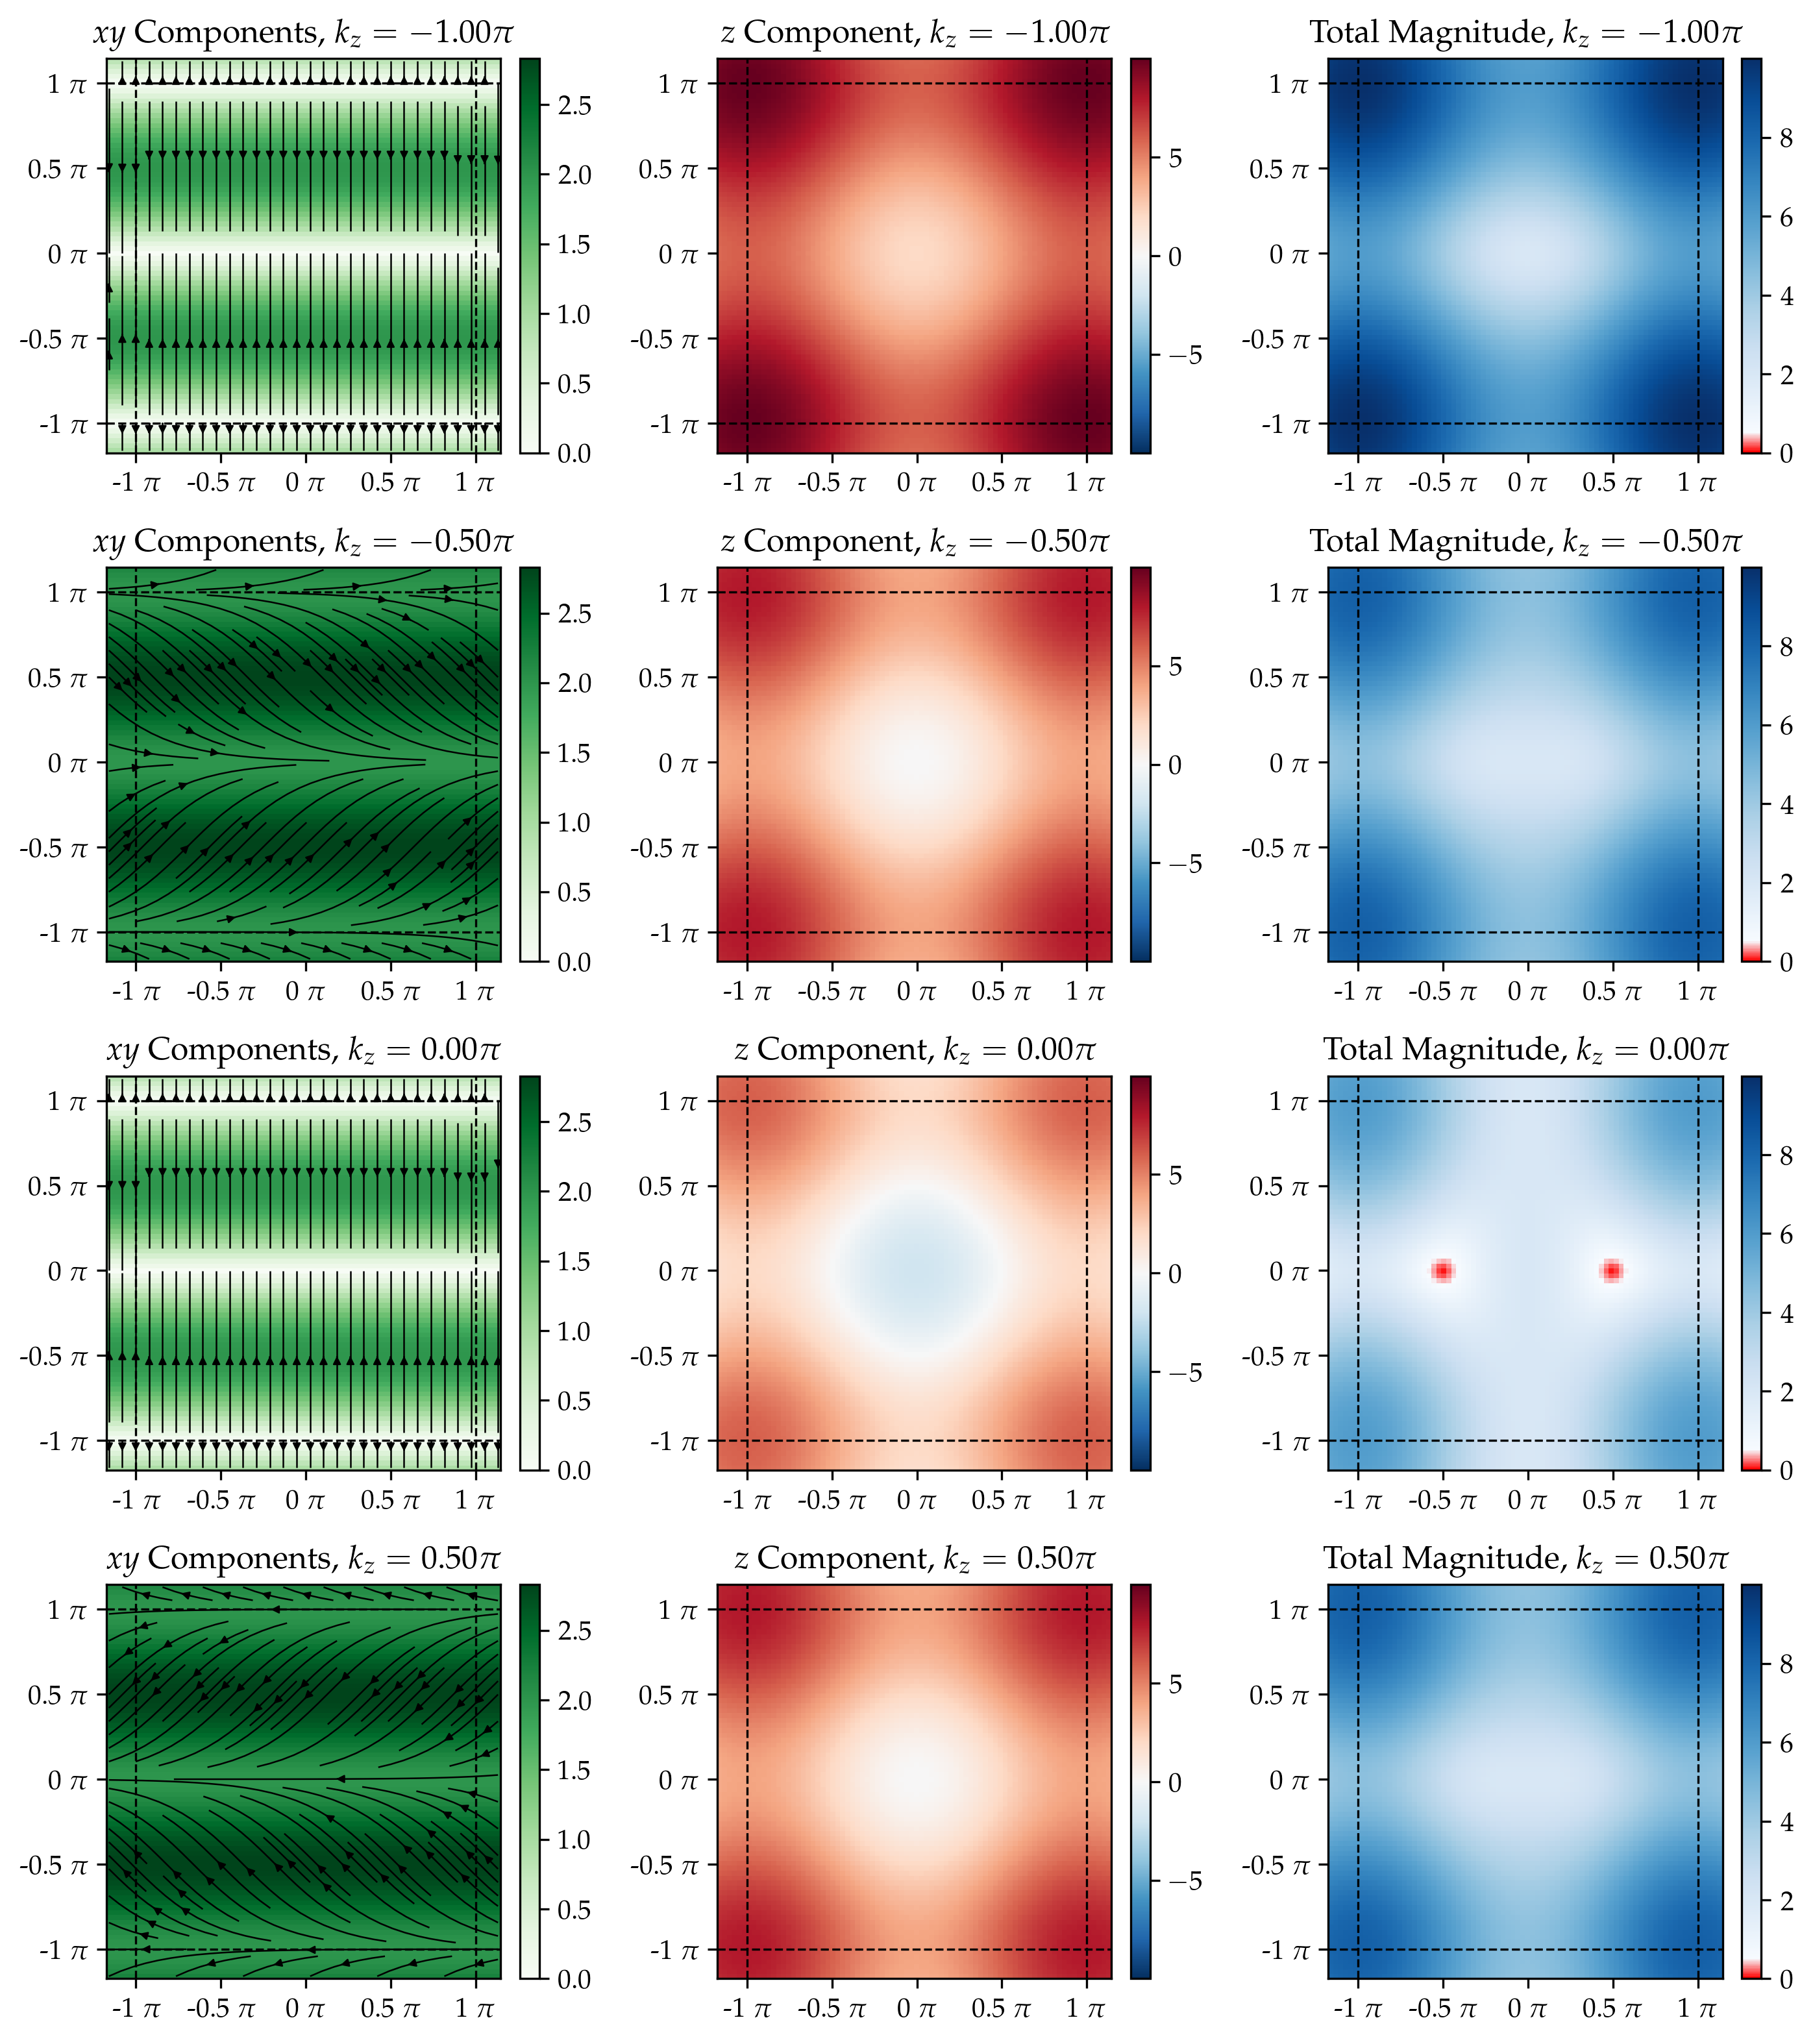

In [153]:
nx = 80
ny = 80
nz = 4
kx = np.linspace(-np.pi - 0.5, np.pi + 0.5, nx, endpoint=False)
ky = np.linspace(-np.pi - 0.5, np.pi + 0.5, ny, endpoint=False)
kz = np.linspace(-np.pi, np.pi, nz, endpoint=False)


# A weyl fermion toy model
u = 2
t_values = {
    (0, 0, 0): np.array([0, 0, 0, u]),
    (1, 0, 0): np.array([0, 0, 0, -1]),
    (0, 1, 0): np.array([0, 0, 1j, -1]),
    (0, 0, 1): np.array([0, 1j, 0, -1]),
}

plot_3d_d_matrix(kx, ky, kz, lambda k: d_vector(t_values, k))
plt.tight_layout()
plt.show()

To generate a Hamiltonian we have two requirements. First we specify which hoppings we want to include, which has to be a list of tuples. It helps to sort the list to stop any confusion.

Next we add a series of constraints. These always take the same form 

$(\textup{position}) (\textup{derivative}) (\textup{value})$

A constraint of the form

$(\Gamma) (\beta_x, \beta_y, \beta_z) (d_0, d_x, d_y, d_z)$

demands that 

$\left . \partial_{k_x}^{\beta_x}\partial_{k_y}^{\beta_y}\partial_{k_z}^{\beta_z} H \right |_{k = \Gamma} = \textbf d \cdot \sigma$

All of these constraints are then put together into a set.

In [154]:
allowed_hoppings = sorted(
    [
        (0, 0, 0),
        (1, 0, 0),
        (1, 1, 0),
        (0, 1, 0),
        (1, -1, 0),
        (0, 0, 1),
        # (0, 0, 2),
    ]
)


p = np.pi * 0.5
# this gives the four constraints to put a weyl node at each point, with the chiralities shown
c1 = constraints_from_weyl_node((p, p, 0), (1, -1, +1))
c2 = constraints_from_weyl_node((-p, p, 0), (-1, 1, None))
c3 = constraints_from_weyl_node((p, -p, 0), (-1, 1, None))
c4 = constraints_from_weyl_node((-p, -p, 0), (1, -1, +1))

print(f"The constraints for c1 weyl node are")
print(*c1, sep="\n")
print(f"")

constraints = c1 | c2 | c3 | c4

m, v = total_matrix_from_constraints(constraints, allowed_hoppings)
sol, null_basis = solve_constraint_matrix(m, v)

coeffs = np.random.randn(null_basis.shape[1])
random_solution = sol + null_basis @ coeffs

t = vector_to_t_values(random_solution, allowed_hoppings)

t_flat = {}
for key in t.keys():
    t_flat[key] = t[key] * np.array([0, 1, 1, 1])

print("t values are:")
for a in t.keys():
    print(a, t_flat[a].real.round(3), t[a].imag.round(3))

# plt.matshow(null_basis.T)

The constraints for c1 weyl node are
((1.5707963267948966, 1.5707963267948966, 0), (0, 0, 1), (0, 0, 0, 1))
((1.5707963267948966, 1.5707963267948966, 0), (0, 1, 0), (0, 0, -1, 0))
((1.5707963267948966, 1.5707963267948966, 0), (1, 0, 0), (0, 1, 0, 0))
((1.5707963267948966, 1.5707963267948966, 0), (0, 0, 0), (0, 0, 0, 0))

t values are:
(0, 0, 0) [ 0.    -0.585  1.503  0.402] [0. 0. 0. 0.]
(0, 0, 1) [ 0.     0.585 -1.503 -0.402] [-0.  0. -0. -1.]
(0, 1, 0) [0. 0. 0. 0.] [-0.  0.  0. -0.]
(1, -1, 0) [-0.    -0.182  0.543  0.021] [ 0.  -0.5 -0.5  0. ]
(1, 0, 0) [ 0.  0. -0.  0.] [ 0. -0.  0.  0.]
(1, 1, 0) [ 0.    -0.182  0.543  0.021] [-0.   0.5 -0.5 -0. ]


Next, we put all these constraints together in the form of a linear set of simultaneous equations which must be solved. These are then passed to the `solve_constraint_matrix` function, which returns a single solution as `sol` and the set of basis vectors that span the full solution space as `nullspace`. Thus, any Hamiltonian that satisfies the constraints can be constructed from these ingredients. Finally, we turn this vector back into a `t_values` like object.

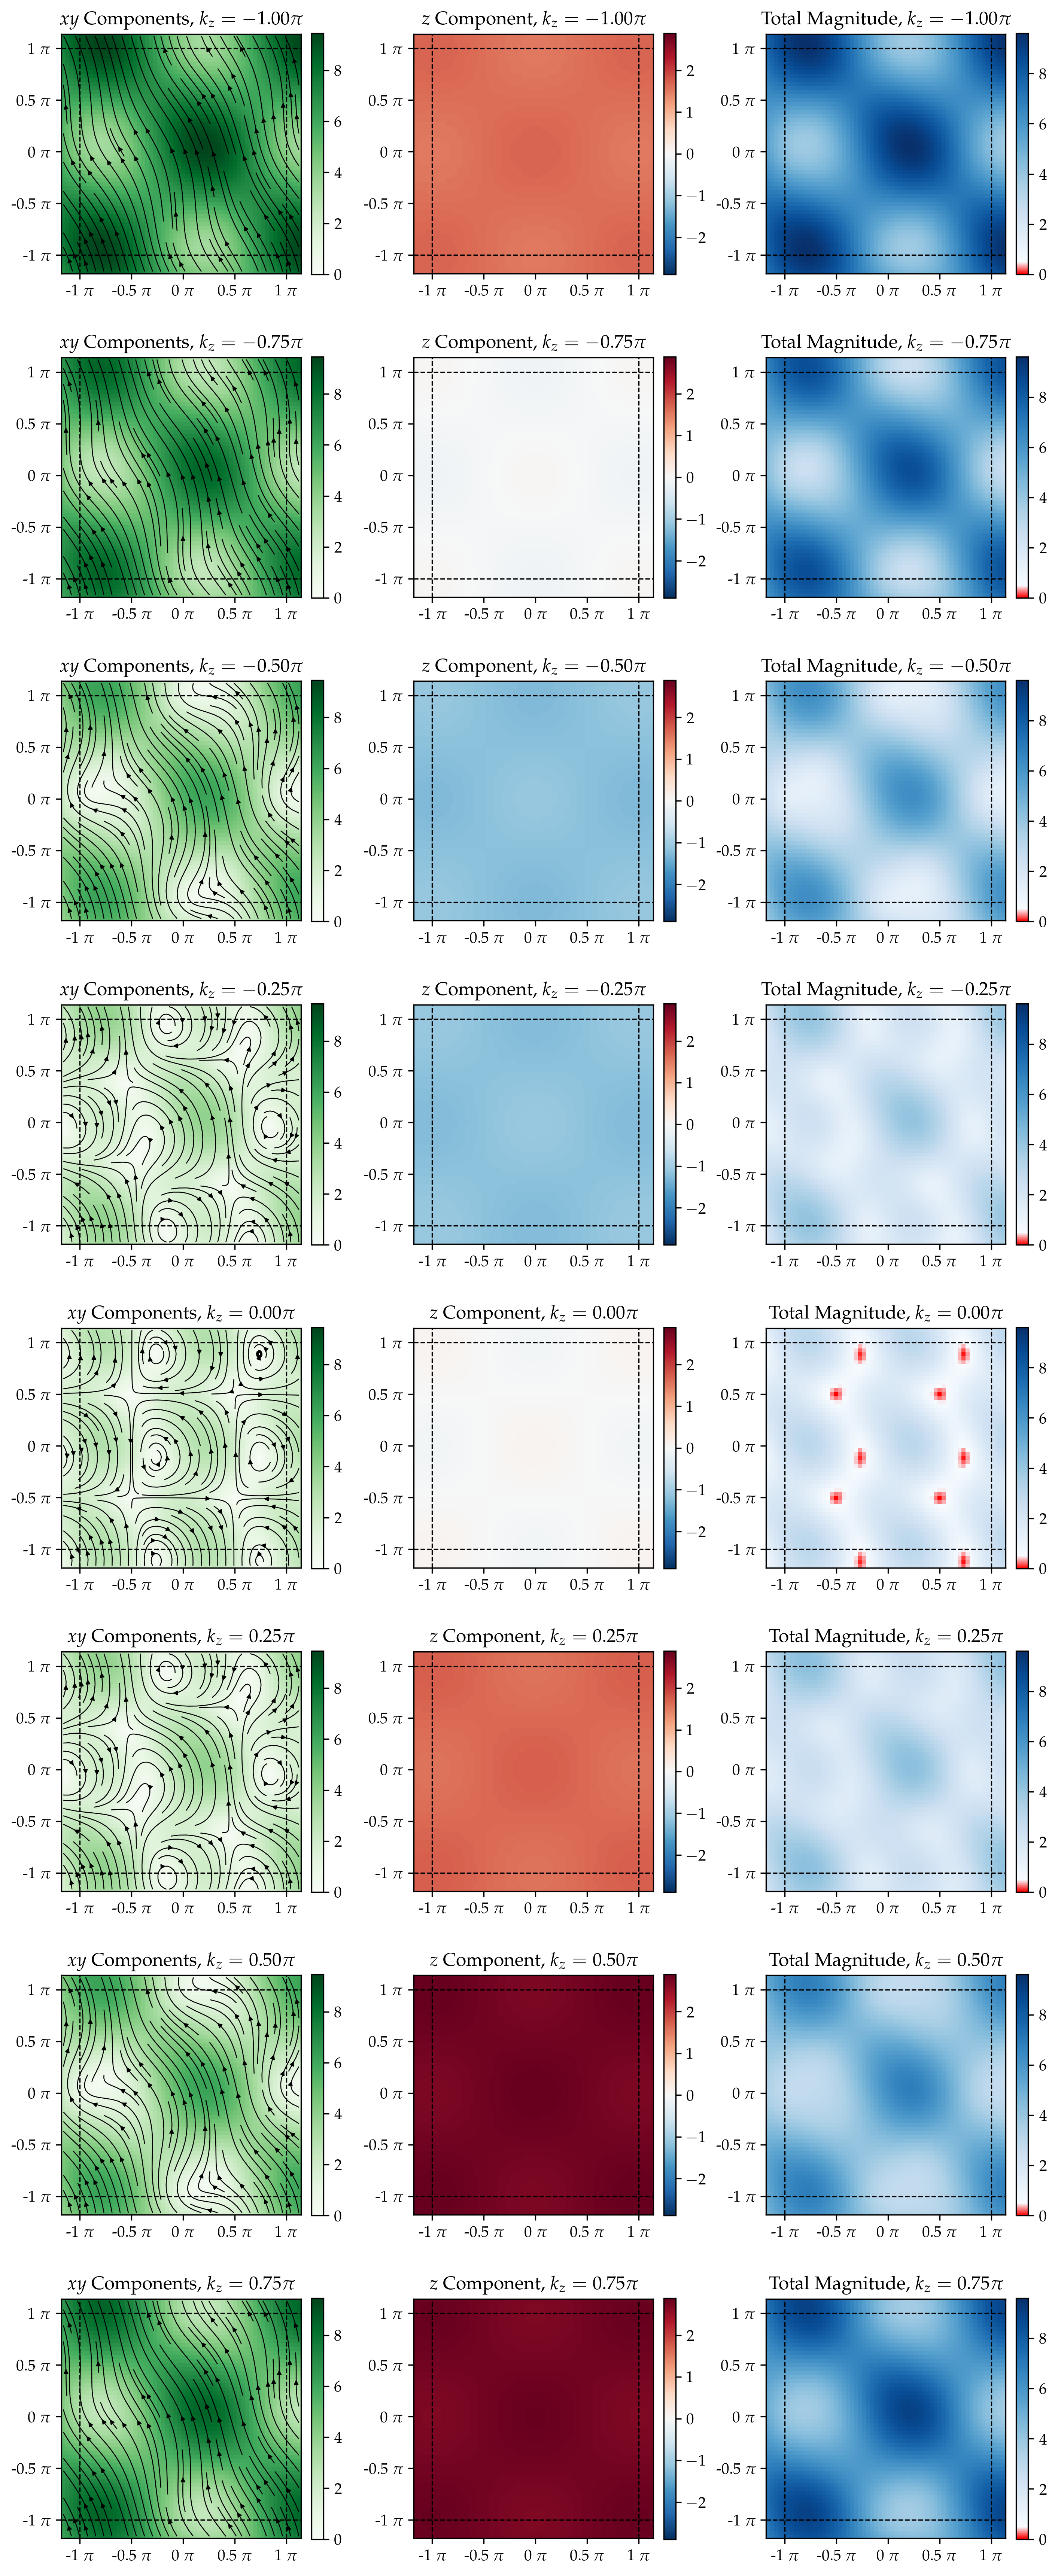

In [155]:
nx = 60
ny = 60

kx = np.linspace(-np.pi - 0.5, np.pi + 0.5, nx, endpoint=False)
ky = np.linspace(-np.pi - 0.5, np.pi + 0.5, ny, endpoint=False)
kz = np.linspace(-np.pi, np.pi, 8, endpoint=False)

plot_3d_d_matrix(kx, ky, kz, lambda k: d_vector(t_flat, k))
plt.tight_layout()
plt.show()

now we can check if the system has the Weyl nodes we crave 

In [156]:
from blochK import Hamiltonian2D
from blochK.hamiltonian_engineering import two_band_hamiltonian_3d
from blochK.plotting import plot_FS


len_z = 50


kx = np.linspace(-np.pi - 0.5, np.pi + 0.5, nx, endpoint=False)
ky = np.linspace(-np.pi - 0.5, np.pi + 0.5, ny, endpoint=False)
KX, KY = np.meshgrid(kx, ky)

h_open = two_band_hamiltonian_3d(KX, KY, t_flat, len_z, True)
h_closed = two_band_hamiltonian_3d(KX, KY, t_flat, len_z, False)

energies_open = np.linalg.eigvalsh(np.einsum("ijkl -> klij", h_open))
energies_open = np.einsum("ijk->kij", energies_open)

energies_closed = np.linalg.eigvalsh(np.einsum("ijkl -> klij", h_closed))
energies_closed = np.einsum("ijk->kij", energies_closed)

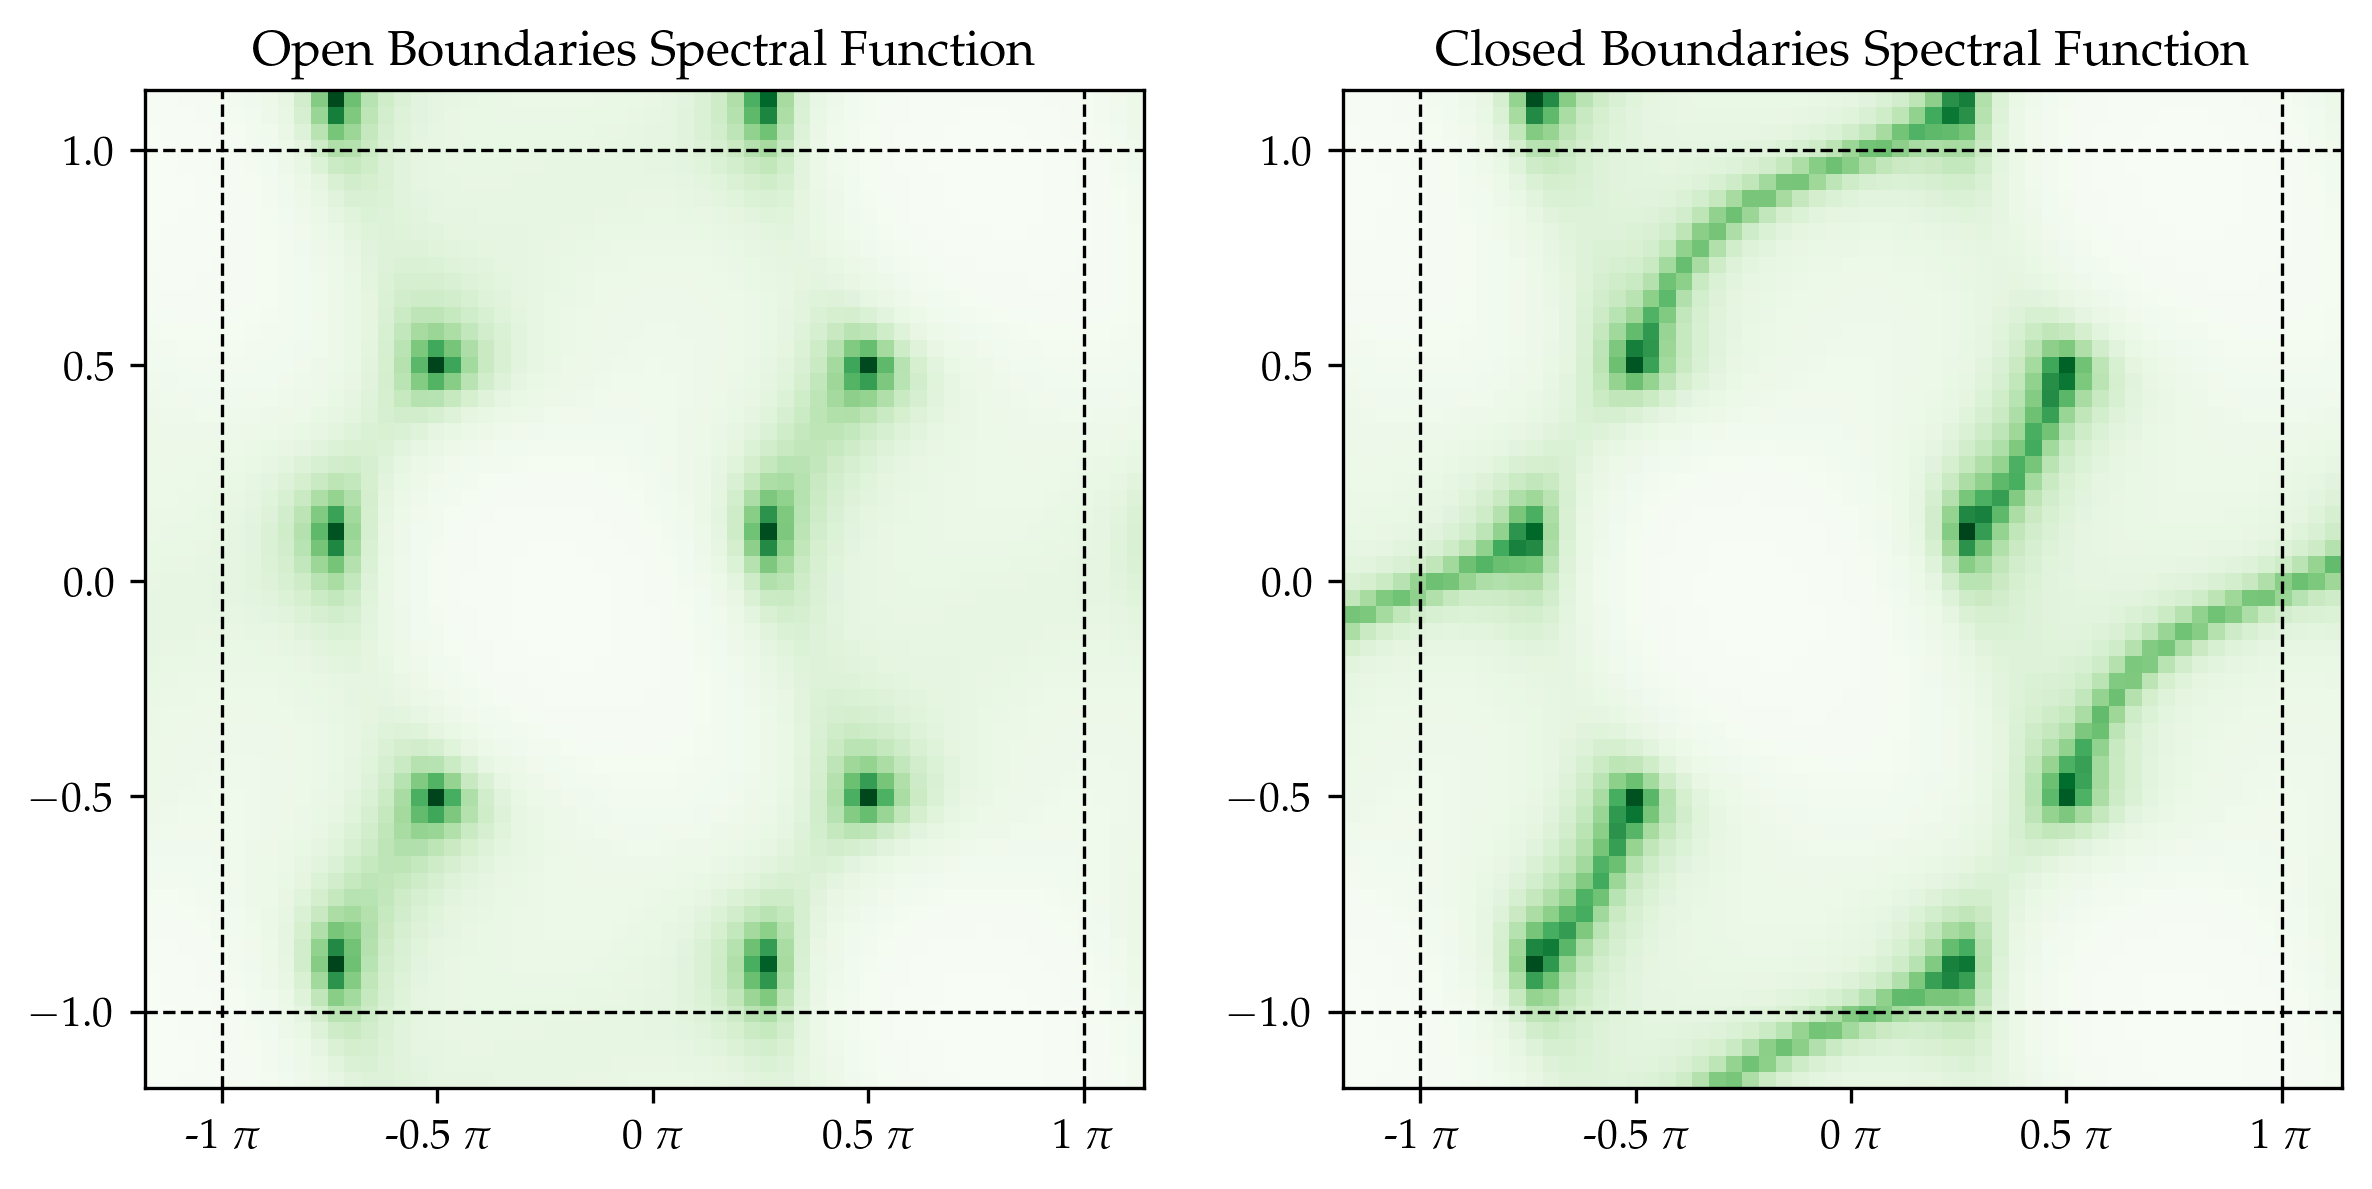

In [157]:
def spectral_func(energies, omega, eta):
    e_shift = energies - omega
    vals = eta / (e_shift**2 + eta**2)
    return np.sum(vals / np.pi, axis=0)


omega = 0.0
eta = 0.2
document_width = 240
figwidth = document_width / 25.4
figheight = figwidth / 2
fig, ax = plt.subplots(1, 2, figsize=(document_width / 25.4, figheight), dpi=300)
ax[0].pcolor(
    KX / np.pi,
    KY / np.pi,
    spectral_func(energies_closed, omega, eta),
    cmap="Greens",
)
ax[1].pcolor(
    KX / np.pi,
    KY / np.pi,
    spectral_func(energies_open, omega, eta),
    cmap="Greens",
)

ax[0].set_title("Open Boundaries Spectral Function")
ax[1].set_title("Closed Boundaries Spectral Function")


for a in ax:
    a.set_aspect("equal")
    a.axhline(1, linestyle="--", c="k", linewidth=0.8)
    a.axhline(-1, linestyle="--", c="k", linewidth=0.8)
    a.axvline(1, linestyle="--", c="k", linewidth=0.8)
    a.axvline(-1, linestyle="--", c="k", linewidth=0.8)

    a.xaxis.set_major_formatter(tck.FormatStrFormatter(r"%g $\pi$"))
    a.xaxis.set_major_locator(tck.MultipleLocator(base=0.5))